In [36]:
# Importing libraries :
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [37]:
# Loading the dataset :
df = pd.read_csv("Dataset.csv")
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [38]:
# Checking rows and columns of dataset :
df.shape

(9551, 21)

In [39]:
# Checking dataset structure, data types, and null values :
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

In [40]:
# Checking missing values : 
df.isnull().sum()

Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

In [41]:
# Checking duplicates :
df.duplicated().sum()

np.int64(0)

In [42]:
# Displaying statistical summary : 
df.describe()

,Restaurant ID,Country Code,Longitude,Latitude,Average Cost for two,Price range,Aggregate rating,Votes
count,9.551000e+03,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000,9551.000000
mean,9.051128e+06,18.365616,64.126574,25.854381,1199.210763,1.804837,2.666370,156.909748
std,8.791521e+06,56.750546,41.467058,11.007935,16121.183073,0.905609,1.516378,430.169145
min,5.300000e+01,1.000000,-157.948486,-41.330428,0.000000,1.000000,0.000000,0.000000
25%,3.019625e+05,1.000000,77.081343,28.478713,250.000000,1.000000,2.500000,5.000000
50%,6.004089e+06,1.000000,77.191964,28.570469,400.000000,2.000000,3.200000,31.000000
75%,1.835229e+07,1.000000,77.282006,28.642758,700.000000,2.000000,3.700000,131.000000
max,1.850065e+07,216.000000,174.832089,55.976980,800000.000000,4.000000,4.900000,10934.000000


In [43]:
# Filling missing cuisine values :
df["Cuisines"] = df["Cuisines"].fillna("unknown")

# Level 1

In [44]:
# TASK - 1
# 1. Determine the top three most common cuisines in the dataset :

top_cuisines = df['Cuisines'].str.split(', ').explode().value_counts().head(3)
top_cuisines

Cuisines
North Indian    3960
Chinese         2735
Fast Food       1986
Name: count, dtype: int64

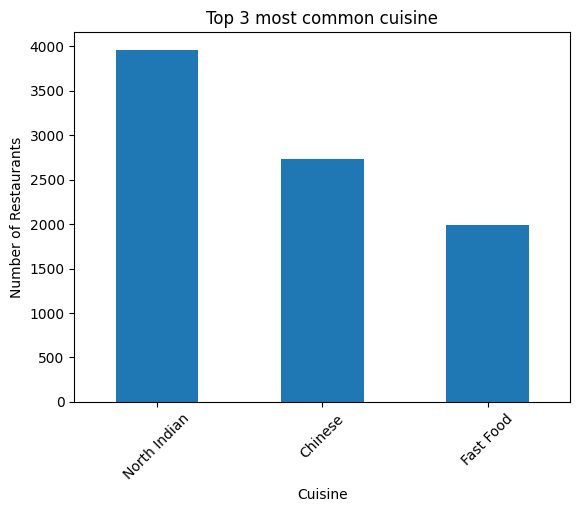

In [45]:
# Creating bar chart for top 3 cuisines :

top_cuisines.plot(kind = "bar")
plt.title("Top 3 most common cuisine")
plt.xlabel("Cuisine")
plt.ylabel("Number of Restaurants")
plt.xticks(rotation = 45)
plt.show()

In [46]:
# 2. Calculate the percentage of restaurants that serve each of the top cuisines : 

cuisine_percentage = (top_cuisines / len(df)) * 100
cuisine_percentage

Cuisines
North Indian    41.461627
Chinese         28.635745
Fast Food       20.793634
Name: count, dtype: float64

In [47]:
# TASK - 2
# 1. Identify the city with the highest number of restaurants in the dataset : 

# Counting total restaurants in each city : 
city_count = df['City'].value_counts()

# Finding city with highest number of restaurants : 
top_city = city_count.idxmax()
top_city_count = city_count.max()

print("City with highest restaurants :", top_city)
print("Total restaurants :", top_city_count)


City with highest restaurants : New Delhi
Total restaurants : 5473


In [48]:
# 2. Calculate the average rating for restaurants in each city : 

city_avg_rating = df.groupby("City")["Aggregate rating"].mean().sort_values(ascending = False)
city_avg_rating

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
                      ...   
New Delhi           2.438845
Montville           2.400000
Mc Millan           2.400000
Noida               2.036204
Faridabad           1.866932
Name: Aggregate rating, Length: 141, dtype: float64

In [49]:
# 3. Determine the city with the highest average rating :

highest_rated_city = city_avg_rating.idxmax()
highest_avg_rating = city_avg_rating.max()

print("City with highest avg rating : ", highest_rated_city)
print("Average rating : ", highest_avg_rating)

City with highest avg rating :  Inner City
Average rating :  4.9


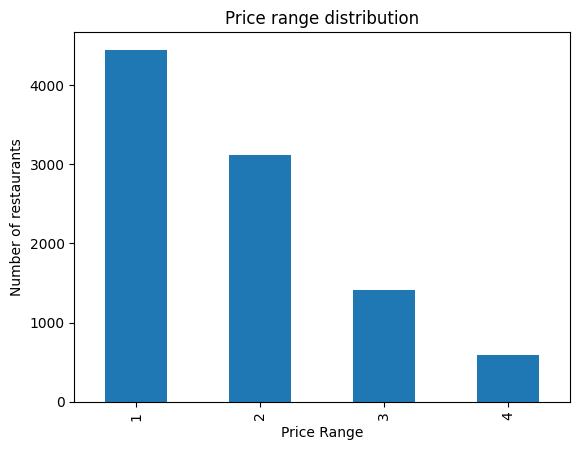

In [50]:
# TASK - 3
# 1. Create a histogram or bar chart to visualize the distribution of price ranges among the restaurants :

price_distribution = df["Price range"].value_counts().sort_index()

price_distribution.plot(kind = "bar")
plt.title("Price range distribution")
plt.xlabel("Price Range")
plt.ylabel("Number of restaurants")
plt.show()

In [51]:
# 2. Calculate the percentage of restaurants in each price range category :

price_percentage = (price_distribution / len(df)) * 100
price_percentage

Price range
1    46.529159
2    32.593446
3    14.741912
4     6.135483
Name: count, dtype: float64

In [52]:
# TASK - 4
# 1. Determine the percentage of restaurants that offer online delivery :

online_delivery_count = df["Has Online delivery"].value_counts()

online_delivery_percentage = (online_delivery_count / len(df)) * 100
online_delivery_percentage

Has Online delivery
No     74.337766
Yes    25.662234
Name: count, dtype: float64

In [53]:
# 2. Compare the average ratings of restaurants with and without online delivery :

avg_delivery_rating = df.groupby("Has Online delivery")["Aggregate rating"].mean()
avg_delivery_rating 

Has Online delivery
No     2.465296
Yes    3.248837
Name: Aggregate rating, dtype: float64

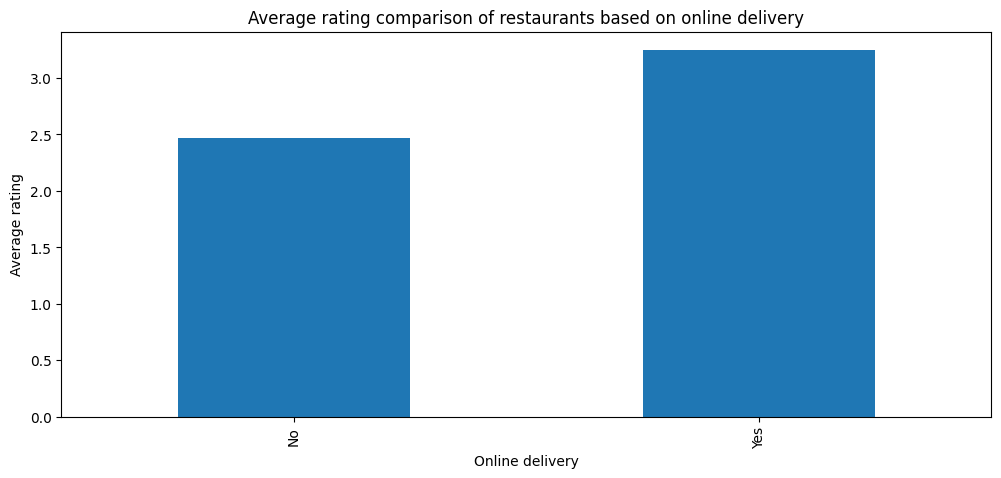

In [54]:
# Creating bar chart for average rating comparison :

plt.figure(figsize = (12, 5))
avg_delivery_rating.plot(kind = "bar")
plt.title("Average rating comparison of restaurants based on online delivery")
plt.xlabel("Online delivery")
plt.ylabel("Average rating")
plt.show()

# Level 2 

In [55]:
# 1. Analyze the distribution of aggregate ratings and determine the most common rating range :

rating_distribution = df["Aggregate rating"].value_counts().sort_index()
rating_distribution

Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64

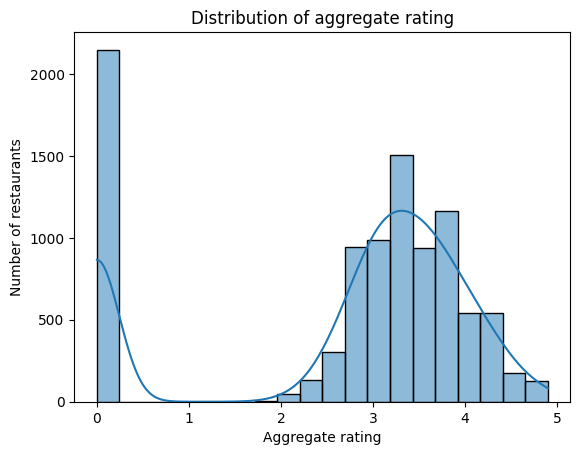

In [56]:
# Creating histogram for aggregate ratings : 

sns.histplot(df["Aggregate rating"], bins = 20, kde = True)
plt.title("Distribution of aggregate rating")
plt.xlabel("Aggregate rating")
plt.ylabel("Number of restaurants")
plt.show()

In [57]:
# Determining the most common range :
rating_range = pd.cut(df["Aggregate rating"], bins = [0, 1, 2, 3, 4, 5])

most_common_range = rating_range.value_counts()
most_common_range

Aggregate rating
(3, 4]    4388
(2, 3]    1891
(4, 5]    1114
(1, 2]      10
(0, 1]       0
Name: count, dtype: int64

In [58]:
# 2. Calculate the average number of votes received by restaurants :

average_votes = df["Votes"].mean()
average_votes

np.float64(156.909747670401)

In [59]:
# TASK - 2
# 1. Identify the most common combinations of cuisines in the dataset :

cuisine_combination = df["Cuisines"].value_counts().head(10)
cuisine_combination

Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64

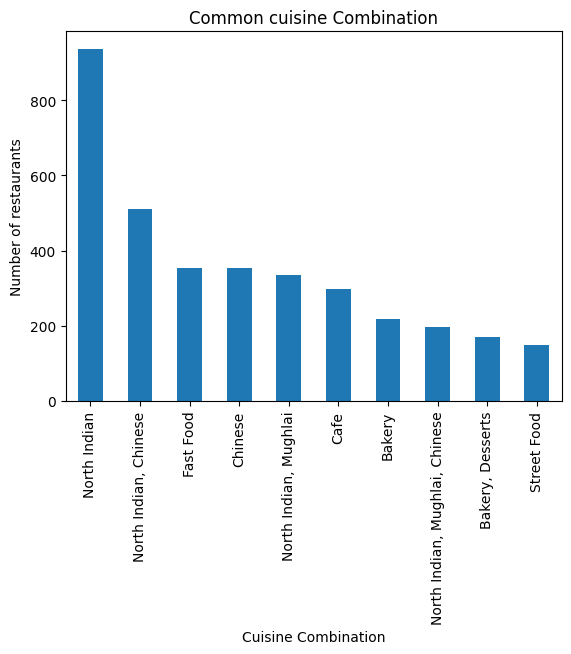

In [60]:
# Creating bar chart for most common cuisine combination : 

cuisine_combination.plot(kind = "bar")
plt.title("Common cuisine Combination")
plt.xlabel("Cuisine Combination")
plt.ylabel("Number of restaurants")
plt.show()

In [61]:
# 2. Determine if certain cuisine combinations tend to have higher ratings :

cuisine_rating = df.groupby("Cuisines")["Aggregate rating"].mean().sort_values(ascending = False).head(10)
cuisine_rating

Cuisines
Italian, Deli                      4.9
American, Coffee and Tea           4.9
American, BBQ, Sandwich            4.9
BBQ, Breakfast, Southern           4.9
Italian, Bakery, Continental       4.9
American, Burger, Grill            4.9
Hawaiian, Seafood                  4.9
Mexican, American, Healthy Food    4.9
American, Caribbean, Seafood       4.9
Mughlai, Lucknowi                  4.9
Name: Aggregate rating, dtype: float64

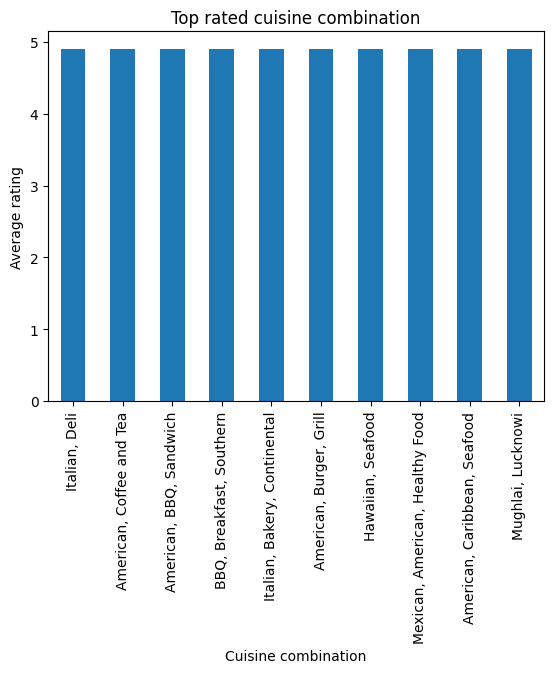

In [62]:
# Visualizing top rated cuisine combinations

cuisine_rating.plot(kind = "bar")
plt.title("Top rated cuisine combination")
plt.xlabel("Cuisine combination")
plt.ylabel("Average rating")
plt.show()

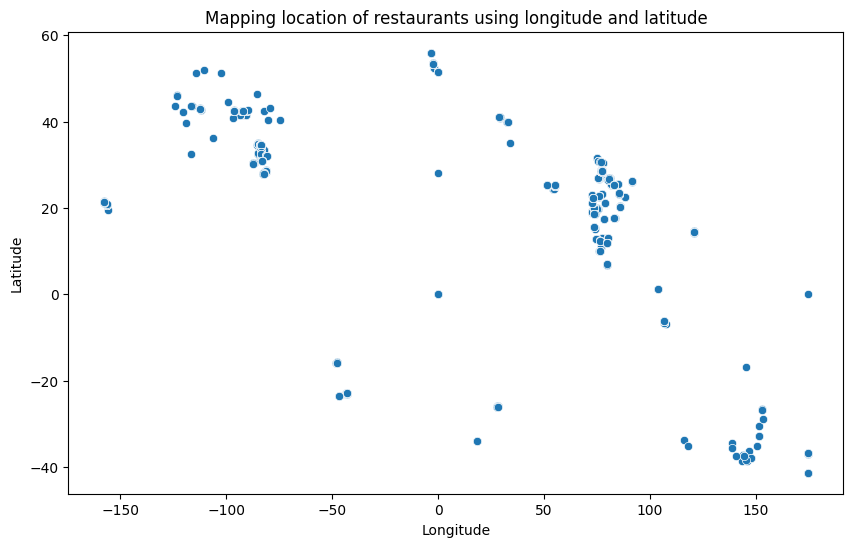

In [63]:
# Task - 3
# 1. Plot the locations of restaurants on a map using longitude and latitude coordinates :

plt.figure(figsize = (10, 6))
sns.scatterplot(x = df["Longitude"], y = df["Latitude"])
plt.title("Mapping location of restaurants using longitude and latitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [64]:
# 2. Identify any patterns or clusters of restaurants in specific areas :

city_location = df.groupby("City")[["Longitude", "Latitude"]].mean().head(10)
city_location

# This calculates average location coordinates for each city.

,Longitude,Latitude
City,,
Abu Dhabi,54.405998,24.464269
Agra,54.622830,19.016683
Ahmedabad,72.531324,23.036910
Albany,-84.186592,31.602963
Allahabad,61.378793,19.089371
Amritsar,60.613098,25.611153
Ankara,32.824276,39.906429
Armidale,151.668879,-30.514717
Athens,-83.380491,33.953808


In [65]:
# Task - 4
# 1. Identify if there are any restaurant chains present in the dataset :

restaurant_chain = df["Restaurant Name"].value_counts()
restaurant_chain = restaurant_chain[restaurant_chain > 1]

restaurant_chain.head(10)

Restaurant Name
Cafe Coffee Day     83
Domino's Pizza      79
Subway              63
Green Chick Chop    51
McDonald's          48
Keventers           34
Pizza Hut           30
Giani               29
Baskin Robbins      28
Barbeque Nation     26
Name: count, dtype: int64

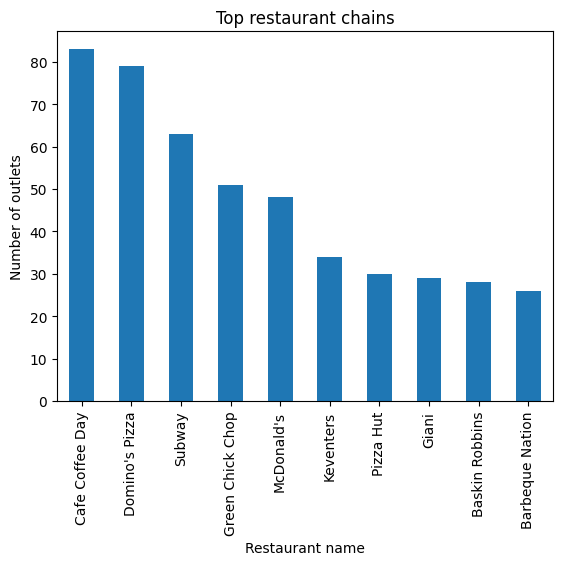

In [66]:
# Creating bar charts for top restaurant chains : 

restaurant_chain.head(10).plot(kind = "bar")
plt.title("Top restaurant chains")
plt.xlabel("Restaurant name")
plt.ylabel("Number of outlets")
plt.show()

In [67]:
# 2. Analyze the ratings and popularity of different restaurant chains : 

chain_rating = df.groupby("Restaurant Name")["Aggregate rating"].mean()
chain_rating = chain_rating[restaurant_chain.index].sort_values(ascending = False)

chain_rating.head(10)

Restaurant Name
Talaga Sampireun             4.900
Silantro Fil-Mex             4.850
AB's Absolute Barbecues      4.850
AB's - Absolute Barbecues    4.825
Naturals Ice Cream           4.800
Gymkhana                     4.700
The Cheesecake Factory       4.650
Dishoom                      4.600
Garota de Ipanema            4.600
Chili's                      4.580
Name: Aggregate rating, dtype: float64

In [68]:
# Calculating average votes of restaurant chains :

voting_chain = df.groupby("Restaurant Name")["Votes"].mean()
voting_chain = voting_chain[restaurant_chain.index].sort_values(ascending = False)

voting_chain.head(10)

Restaurant Name
Truffles                     4841.000000
Joey's Pizza                 3903.500000
AB's - Absolute Barbecues    3350.000000
Big Chill                    2713.250000
Big Yellow Door              2503.666667
Out Of The Box               2450.000000
Saravana Bhavan              2412.666667
Olive Bistro                 1854.000000
Talaga Sampireun             1838.000000
SpiceKlub                    1825.500000
Name: Votes, dtype: float64

In [69]:
df.to_csv("Cleaned_dataset.csv", index = False)

# Conclusion

1. North Indian, Chinese, and Fast Food are the most common cuisines.
2. Certain cities have a much higher concentration of restaurants.
3. Mid-range price categories have the highest number of restaurants.
4. Many restaurants provide online delivery, and their ratings are competitive.
5. Most restaurants fall in the 3 to 4 rating range.
6. Some cuisine combinations have better ratings than others.
7. Restaurant locations show strong clusters in major cities.
8. Chain restaurants have high popularity and strong customer engagement.